In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import find_peaks
from scipy.stats import linregress

In [3]:
data = pd.read_csv("Magnetic_field_data.csv")
print(data.head())

#cleaning data
columns = ['Time (s)','ωy (rad/s)','Voltage (mV)']
data = data[columns]
print(data)

   Time (s)   Bx (µT)    By (µT)    Bz (µT)  ωy (rad/s)  Voltage (mV)
0      0.01 -6.646662  18.585100  71.878098   -0.023669      0.007326
1      0.02 -5.742698  18.898506  73.053688   -0.018472      0.009418
2      0.03 -5.752046  18.895266  73.041534   -0.022262      0.007327
3      0.04 -6.339109  18.691730  72.278069   -0.019409      0.009422
4      0.05 -5.052806  19.113710  73.853630   -0.713480      0.012560
       Time (s)  ωy (rad/s)  Voltage (mV)
0      0.010000   -0.023669      0.007326
1      0.020000   -0.018472      0.009418
2      0.030000   -0.022262      0.007327
3      0.040000   -0.019409      0.009422
4      0.050000   -0.713480      0.012560
...         ...         ...           ...
4810  48.110001   -1.577355      0.008374
4811  48.119999   -1.607389      0.008373
4812  48.130001   -1.636095      0.009419
4813  48.139999   -1.667067      0.009419
4814  48.150002   -1.702196      0.008896

[4815 rows x 3 columns]


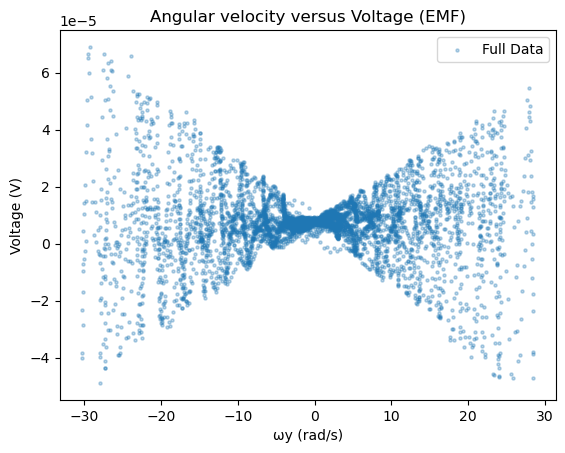

In [4]:
x = data["ωy (rad/s)"]
y = data["Voltage (mV)"] *0.001
plt.scatter(x, y, s=5, alpha=0.3, label="Full Data")
plt.title("Angular velocity versus Voltage (EMF)")
plt.xlabel("ωy (rad/s)")
plt.ylabel("Voltage (V)")
plt.legend()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

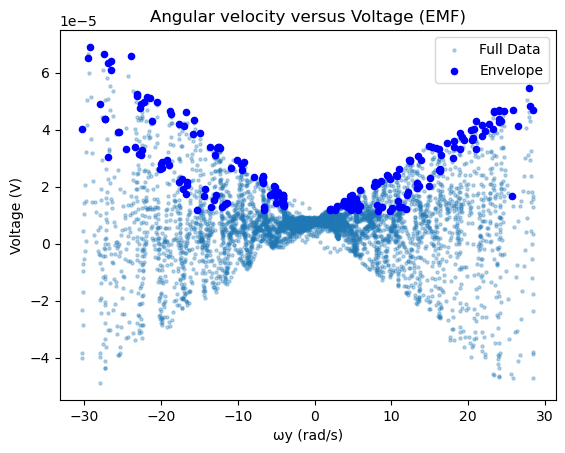

In [5]:
abs_EMF = np.abs(y)
peaks, _ = find_peaks(abs_EMF, height=np.mean(abs_EMF))
omega_peaks = x[peaks]
emf_peaks  = abs_EMF[peaks]

plt.scatter(x, y, s=5, alpha=0.3, label="Full Data")
plt.scatter(omega_peaks, emf_peaks, s=20, color='blue', label="Envelope")
plt.title("Angular velocity versus Voltage (EMF)")
plt.xlabel("ωy (rad/s)")
plt.ylabel("Voltage (V)")
plt.legend()
plt.show

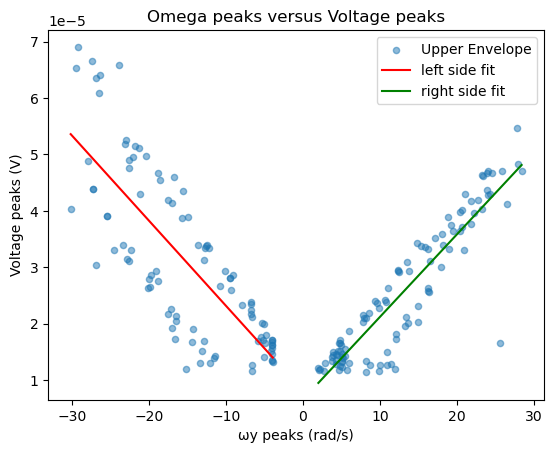

Left-hand linearization:-0.000002x+0.000008
Right-hand linearization:0.000001x+0.000007
Estimated Magnetic feild from right-hand regression: 29955.136nT
Estimated Magnetic feild from left-hand regression: 30883.891nT


In [6]:
omega_upper = omega_peaks
emf_upper   = emf_peaks

mask_left  = omega_upper < 0
omega_left  = omega_upper[mask_left]
emf_left    = emf_upper[mask_left]
slope_left, intercept_left, *_ = linregress(omega_left, emf_left)
omega_fit_left  = np.linspace(min(omega_left), max(omega_left), 200)
emf_fit_left    = slope_left * omega_fit_left + intercept_left

mask_right = omega_upper > 0
omega_right = omega_upper[mask_right]
emf_right   = emf_upper[mask_right]
slope_right, intercept_right, *_ = linregress(omega_right, emf_right)
omega_fit_right = np.linspace(min(omega_right), max(omega_right), 200)
emf_fit_right   = slope_right * omega_fit_right + intercept_right

plt.scatter(omega_upper, emf_upper, s=20, alpha=0.5, label = "Upper Envelope")
plt.plot(omega_fit_left,emf_fit_left , color = "red", label = "left side fit")
plt.plot(omega_fit_right,emf_fit_right, color = "green", label = "right side fit")
plt.title("Omega peaks versus Voltage peaks")
plt.xlabel("ωy peaks (rad/s)")
plt.ylabel("Voltage peaks (V)")
plt.legend()
plt.show()

slope_left, intercept_left, *_ = linregress(omega_left, emf_left)
slope_right, intercept_right, *_ = linregress(omega_right, emf_right)

print(f"Left-hand linearization:{slope_left:.6f}x+{intercept_left:.6f}")
print(f"Right-hand linearization:{slope_right:.6f}x+{intercept_right:.6f}")


N = 5
a = 0.00975
B_left  = abs(slope_left) / (N * a)   
B_right = abs(slope_right) / (N * a)

print(f"Estimated Magnetic feild from right-hand regression: {B_right*1e9:.3f}nT")
print(f"Estimated Magnetic feild from left-hand regression: {B_left*1e9:.3f}nT")
#23027

Text(0.5, 1.0, 'Residual plot: Left hand regression: 1.5759333287344338e-10')

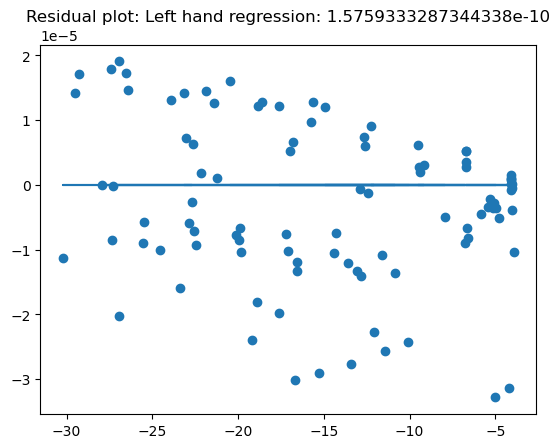

In [13]:
omega_fit_left  = np.linspace(min(omega_left), max(omega_left), 96)
emf_fit_left    = slope_left * omega_fit_left + intercept_left
plt.scatter(omega_left,(emf_left-emf_fit_left))
zero_line = np.zeros(96)
plt.plot(omega_left,zero_line)
Chi_2_left = np.sum((emf_left-emf_fit_left)**2)
Chi_2_left_reduced  = Chi_2_left / 96
plt.title(f"Residual plot: Left hand regression: {Chi_2_left_reduced}")

Text(0.5, 1.0, 'Residual plot: Right hand regression:1.4408533291286252e-10')

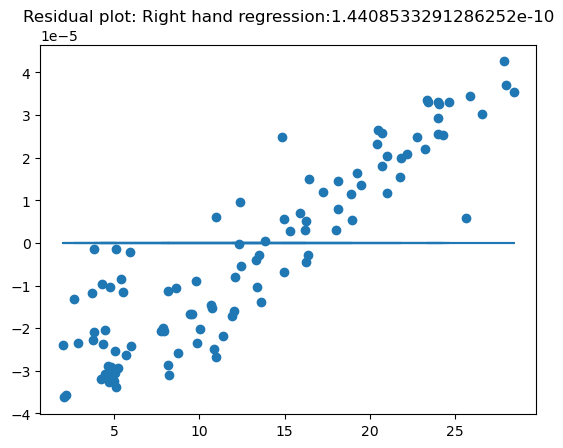

In [14]:
omega_fit_right = np.linspace(min(omega_right), max(omega_right), 105)
emf_fit_right   = slope_right * omega_fit_right + intercept_right
plt.scatter(omega_right,(emf_right-emf_fit_right))
zero_line = np.zeros(105)
plt.plot(omega_right,zero_line)
Chi_2 = np.sum((emf_right-emf_fit_right)**2)
Chi_2_reduced = Chi_2_left /105
plt.title(f"Residual plot: Right hand regression:{Chi_2_reduced}")